# Dynamic Selection of Classifiers
In this file, we reproduce the experiments presented in section 3.2 of the paper

In [1]:
# Loading necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from xgboost import XGBClassifier
from dynsel import *
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
datasets = ['authent',
            "bank-additional-full",
            'diabetes',
            'electricity',
            'gesture',
            'magic',
            'robot',
            'segment',
            'students',
            'texture',
            'twonorm',
            'vowel',
            'wdbc',
            'waveform_21',
            'waveform_40',
            ]

In [3]:
# Configurations for both settings
B=15 # How many times the train-validation-split will be performed
k_cv=5 # folds for cross-validation
k_max = 10 # maximum number of neighbors for the DS strategies in the deslib package
correct=True # Should we apply a correction to robustness if the model gives probability 1 to a class?
ptrain=0.7 # Proportion of data used for testing
pval=.15 # Proportion of data used for validation

## (1) Accuracy when not in the setting of label corruption

In [4]:
acc_ds={}
for file in datasets:
    print("Obtaining the accuracies for the "+file+" dataset.")
    
    # Loading the dataset
    df = pd.read_csv("./datasets/"+file+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    y = np.asarray(y)
    X=np.asarray(X)
    
    # Defining models
    ## Gradient Boosting
    gb = GradientBoostingClassifier(random_state = 8)
    param_grid = {
        'learning_rate': [0.1, 0.2],
        'n_estimators': [100, 200]
    }
    gb_grid = GridSearchCV(gb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## Random Forest
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## XGBoost
    xgb = XGBClassifier(n_jobs = None, random_state = 6)
    param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.5, 1]
    }
    xgb_grid = GridSearchCV(xgb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = 1)

    all_mods=np.array([gb_grid, rf_grid, xgb_grid])
    
    acc_ds[file] = acc_dyn_sel(B, X, y, ptrain, pval, all_mods, noise_frac = 0, k_max = k_max, correct = correct)

Obtaining the accuracies for the authent dataset.
Obtaining the accuracies for the bank-additional-full dataset.
Obtaining the accuracies for the diabetes dataset.
Obtaining the accuracies for the electricity dataset.
Obtaining the accuracies for the gesture dataset.
Obtaining the accuracies for the magic dataset.
Obtaining the accuracies for the robot dataset.
Obtaining the accuracies for the segment dataset.
Obtaining the accuracies for the students dataset.
Obtaining the accuracies for the texture dataset.
Obtaining the accuracies for the twonorm dataset.
Obtaining the accuracies for the vowel dataset.
Obtaining the accuracies for the wdbc dataset.
Obtaining the accuracies for the waveform_21 dataset.
Obtaining the accuracies for the waveform_40 dataset.


In [5]:
# Saving the essential information of the analysis
with open('acc_ds.pickle', 'wb') as handle:
    pickle.dump(acc_ds, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Results for one dataset

In [6]:
with open('acc_ds.pickle', 'rb') as handle:
    acc_ds = pickle.load(handle)

In [7]:
DB='electricity'
mod_names=["GB", "RF", "XGB", "Single Best",
           "MCB", "KNORA-U", "KNORA-E", "META-DES",
           "RS-D", "RS-I"]

In [8]:
df=pd.DataFrame(acc_ds[DB])
df.columns = mod_names
df.describe()

,GB,RF,XGB,Single Best,MCB,KNORA-U,KNORA-E,META-DES,RS-D,RS-I
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,0.867716,0.910209,0.885721,0.910209,0.895332,0.894449,0.896470,0.903864,0.909748,0.910327
std,0.004043,0.003978,0.004313,0.003978,0.004134,0.004380,0.004395,0.003217,0.003975,0.003931
min,0.862018,0.903648,0.877611,0.903648,0.888791,0.886584,0.888055,0.899823,0.904089,0.904089
25%,0.865549,0.908061,0.882980,0.908061,0.892763,0.890924,0.893425,0.901074,0.907326,0.908282
50%,0.866726,0.909974,0.886290,0.909974,0.894381,0.894675,0.895558,0.904089,0.909091,0.909974
75%,0.869594,0.912180,0.888497,0.912180,0.898794,0.897690,0.899529,0.905193,0.910783,0.912327
max,0.877317,0.920712,0.893498,0.920712,0.903207,0.901147,0.903060,0.912033,0.920859,0.920859


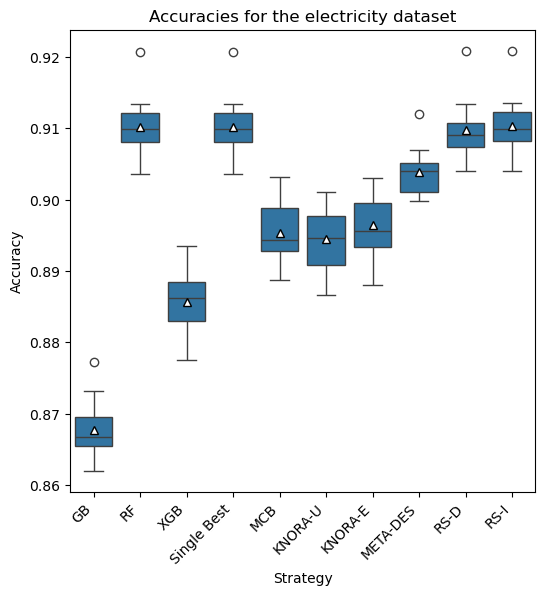

In [9]:
df=pd.DataFrame({'Accuracy': acc_ds[DB].reshape(1,-1).ravel(), 'Strategy':mod_names*len(acc_ds[DB])})

plt.figure(figsize=(6, 6))
ax=sns.boxplot(x='Strategy', y='Accuracy', data=df, showmeans=True,
               meanprops={'markerfacecolor': 'white',  # Fill color
                'markeredgecolor': 'black'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Accuracies for the '+DB+' dataset')
plt.show()

## (2) Accuracy when under label corruption ($\rho = 0.05$)

In [10]:
acc_ds_noise={}
for file in datasets:
    print("Obtaining the accuracies for the "+file+" dataset.")
    
    # Loading the dataset
    df = pd.read_csv("./datasets/"+file+".csv")
    y=df.loc[:,df.columns[-1]]
    if y.dtype == 'object':
        y = pd.Categorical(y).codes
    elif y.dtype=='int':
        y = y-y.min()
    X=df.loc[:,df.columns[:-1]]
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = pd.Categorical(X[col]).codes
    y = np.asarray(y)
    X=np.asarray(X)
    
    # Defining models
    ## Gradient Boosting
    gb = GradientBoostingClassifier(random_state = 8)
    param_grid = {
        'learning_rate': [0.1, 0.2],
        'n_estimators': [100, 200]
    }
    gb_grid = GridSearchCV(gb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## Random Forest
    rf = RandomForestClassifier(random_state = 7)
    param_grid = {
        'n_estimators': [100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [5, None],
        'min_samples_split': [2, 5]
    }
    rf_grid = GridSearchCV(rf, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = -1)
    ## XGBoost
    xgb = XGBClassifier(n_jobs = None, random_state = 6)
    param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.01],
        'subsample': [0.5, 1]
    }
    xgb_grid = GridSearchCV(xgb, param_grid, cv=k_cv, scoring='neg_log_loss', n_jobs = 1)

    all_mods=np.array([gb_grid, rf_grid, xgb_grid])
    
    acc_ds_noise[file] = acc_dyn_sel(B, X, y, ptrain, pval, all_mods, noise_frac = 0.05, k_max = k_max, correct = correct)

Obtaining the accuracies for the authent dataset.
Obtaining the accuracies for the bank-additional-full dataset.
Obtaining the accuracies for the diabetes dataset.
Obtaining the accuracies for the electricity dataset.
Obtaining the accuracies for the gesture dataset.
Obtaining the accuracies for the magic dataset.
Obtaining the accuracies for the robot dataset.
Obtaining the accuracies for the segment dataset.
Obtaining the accuracies for the students dataset.
Obtaining the accuracies for the texture dataset.
Obtaining the accuracies for the twonorm dataset.
Obtaining the accuracies for the vowel dataset.
Obtaining the accuracies for the wdbc dataset.
Obtaining the accuracies for the waveform_21 dataset.
Obtaining the accuracies for the waveform_40 dataset.


In [11]:
# Saving the essential information of the analysis
with open('acc_ds_noise.pickle', 'wb') as handle:
    pickle.dump(acc_ds_noise, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Results for one dataset

In [12]:
with open('acc_ds_noise.pickle', 'rb') as handle:
    acc_ds_noise = pickle.load(handle)

In [13]:
DB='magic'
mod_names=["GB", "RF", "XGB", "Single Best",
           "MCB", "KNORA-U", "KNORA-E", "META-DES",
           "RS-D", "RS-I"]

In [14]:
df=pd.DataFrame(acc_ds_noise[DB])
df.columns = mod_names
df.describe()

,GB,RF,XGB,Single Best,MCB,KNORA-U,KNORA-E,META-DES,RS-D,RS-I
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,0.874609,0.881056,0.876548,0.877832,0.876641,0.878346,0.877669,0.878743,0.879935,0.878206
std,0.006473,0.004996,0.007547,0.007541,0.006205,0.005774,0.006129,0.006464,0.006783,0.006946
min,0.861598,0.868255,0.859495,0.861598,0.864751,0.866503,0.864401,0.862999,0.861948,0.861948
25%,0.871934,0.879467,0.872460,0.875263,0.871058,0.875788,0.875613,0.876139,0.877365,0.875263
50%,0.875964,0.881570,0.879818,0.879818,0.878416,0.879117,0.878416,0.878767,0.879467,0.879467
75%,0.878591,0.884198,0.882270,0.881745,0.881044,0.882270,0.879818,0.881570,0.884022,0.881920
max,0.885074,0.889278,0.884373,0.889278,0.885774,0.887176,0.887877,0.891381,0.889979,0.888928


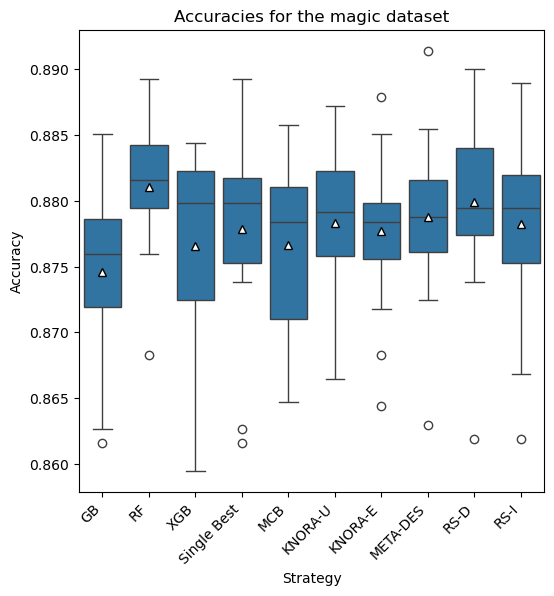

In [15]:
df=pd.DataFrame({'Accuracy': acc_ds_noise[DB].reshape(1,-1).ravel(), 'Strategy':mod_names*len(acc_ds_noise[DB])})

plt.figure(figsize=(6, 6))
ax=sns.boxplot(x='Strategy', y='Accuracy', data=df, showmeans=True,
               meanprops={'markerfacecolor': 'white',  # Fill color
                'markeredgecolor': 'black'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Accuracies for the '+DB+' dataset')
plt.show()